In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
nav_hist = pd.read_csv("../data/processed/cleaned_nav_history.csv")

performance = pd.read_csv("../data/processed/cleaned_performance.csv")

transactions = pd.read_csv("../data/processed/cleaned_transactions.csv")

aum_fund = pd.read_csv("../data/processed/cleaned_aum_fund.csv")

monthly_sip = pd.read_csv("../data/processed/cleaned_monthly_sip.csv")

category_in = pd.read_csv("../data/processed/cleaned_category_in.csv")

folio_count = pd.read_csv("../data/processed/cleaned_folio_count.csv")

port_holdings = pd.read_csv("../data/processed/cleaned_port_holdings.csv")

benchmark_indices = pd.read_csv("../data/processed/cleaned_benchmark_indices.csv")

fund_master = pd.read_csv("../data/processed/cleaned_fund_master.csv")

In [5]:
print(nav_hist.shape)
print(performance.shape)
print(transactions.shape)
print(aum_fund.shape)
print(monthly_sip.shape)
print(category_in.shape)
print(folio_count.shape)
print(port_holdings.shape)
print(benchmark_indices.shape)
print(fund_master.shape)

(46000, 3)
(40, 19)
(32778, 13)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(322, 8)
(8050, 3)
(40, 15)


In [6]:
print(nav_hist.columns)

print(performance.columns)

print(transactions.columns)

print(aum_fund.columns)

print(monthly_sip.columns)

print(category_in.columns)

print(folio_count.columns)

print(port_holdings.columns)

print(benchmark_indices.columns)

print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
Index(['month', 'category', 'net_inflow_crore'], dtype='object')
Index(['month', 'total_folios_crore', 'equity_

# NAV Trend Analysis

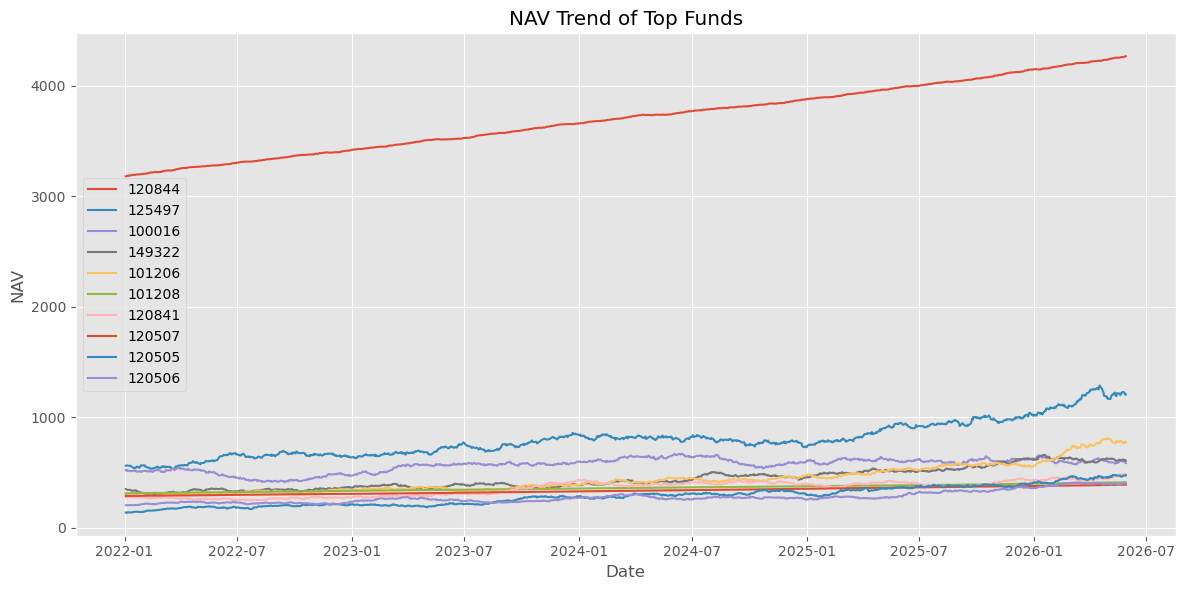

In [23]:
nav_hist["date"] = pd.to_datetime(nav_hist["date"])

top_funds = (
    nav_hist.groupby("amfi_code")["nav"]
    .mean()
    .nlargest(10)
    .index
)

plt.figure(figsize=(12,6))

for code in top_funds:
    temp = nav_hist[nav_hist["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.title("NAV Trend of Top Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.tight_layout()
plt.savefig("../reports/figures/nav_trend.png")
plt.show()

# AUM Growth Analysis

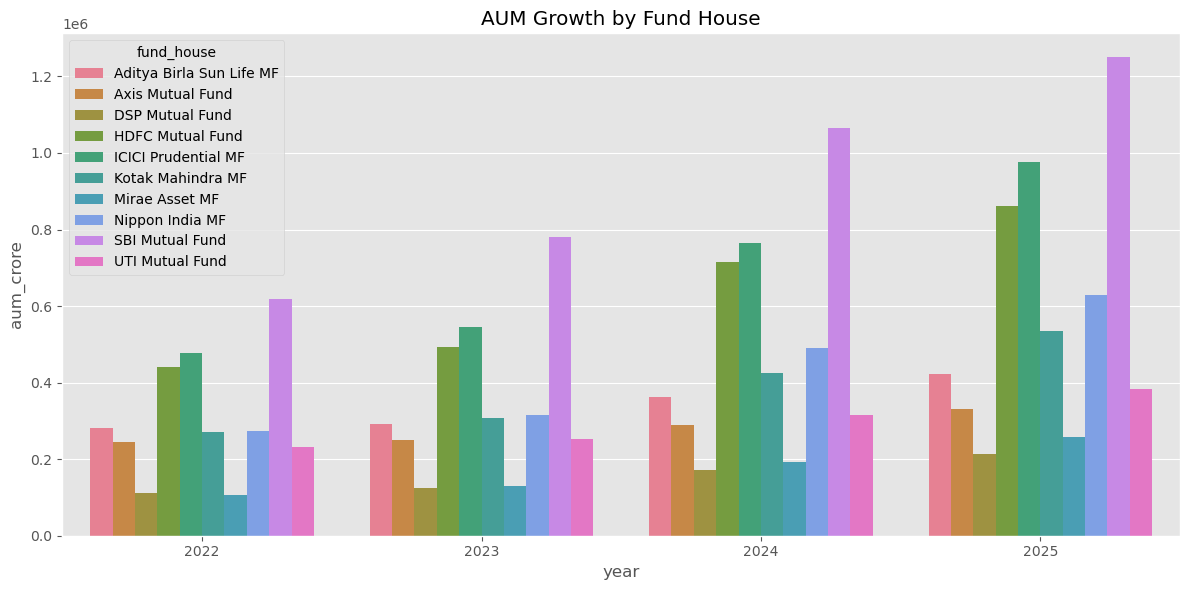

In [24]:
aum_fund["date"] = pd.to_datetime(aum_fund["date"])

aum_fund["year"] = aum_fund["date"].dt.year

annual_aum = (
    aum_fund.groupby(
        ["year","fund_house"]
    )["aum_crore"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=annual_aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.tight_layout()
plt.savefig("../reports/figures/aum_growth.png")
plt.show()

# SIP Inflow Trend

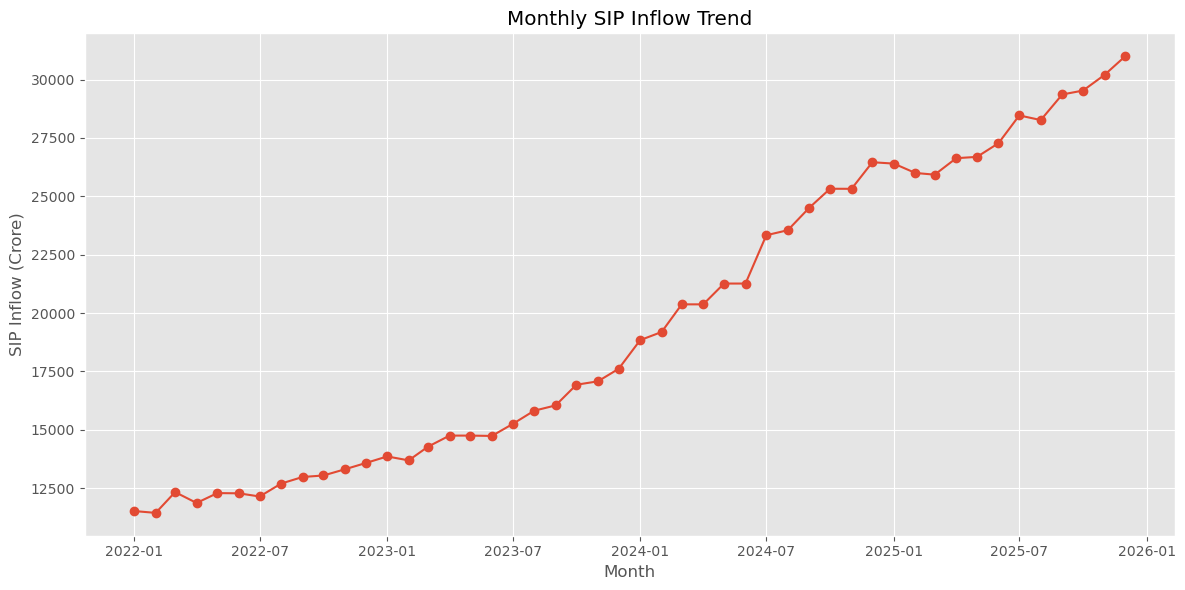

In [25]:
monthly_sip["month"] = pd.to_datetime(
    monthly_sip["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sip["month"],
    monthly_sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.tight_layout()
plt.savefig("../reports/figures/sip_inflow.png")
plt.show()

# Category Inflow Heatmap

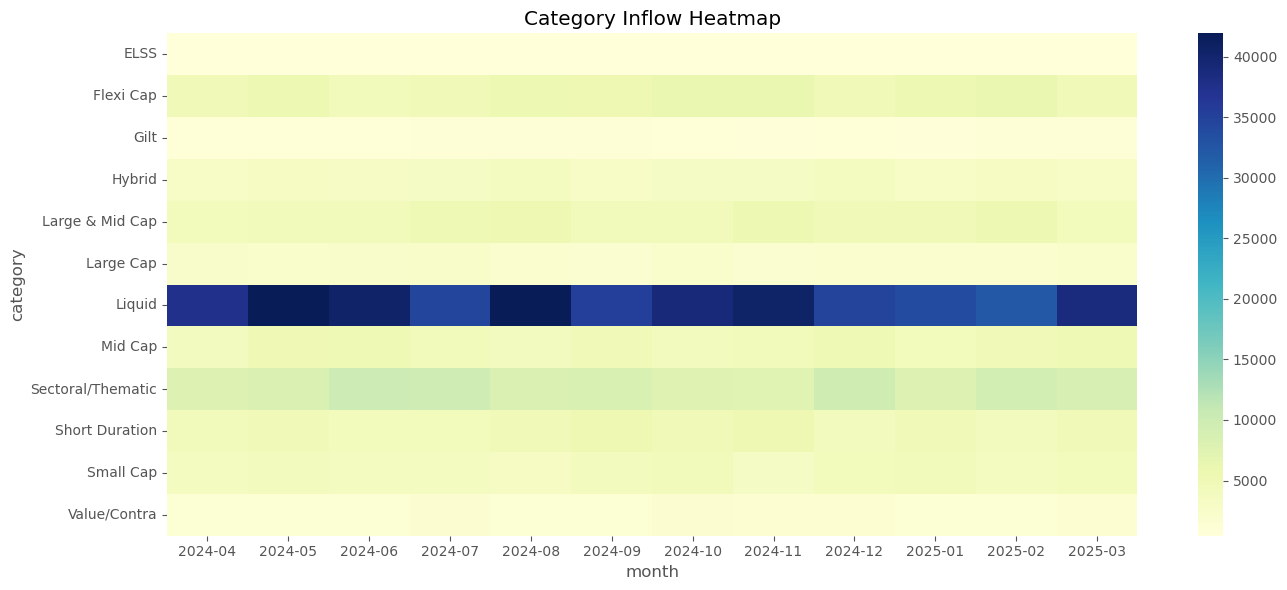

In [26]:
heatmap_data = category_in.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.tight_layout()
plt.savefig("../reports/figures/category_inflow.png")
plt.show()

# Investor Demographics

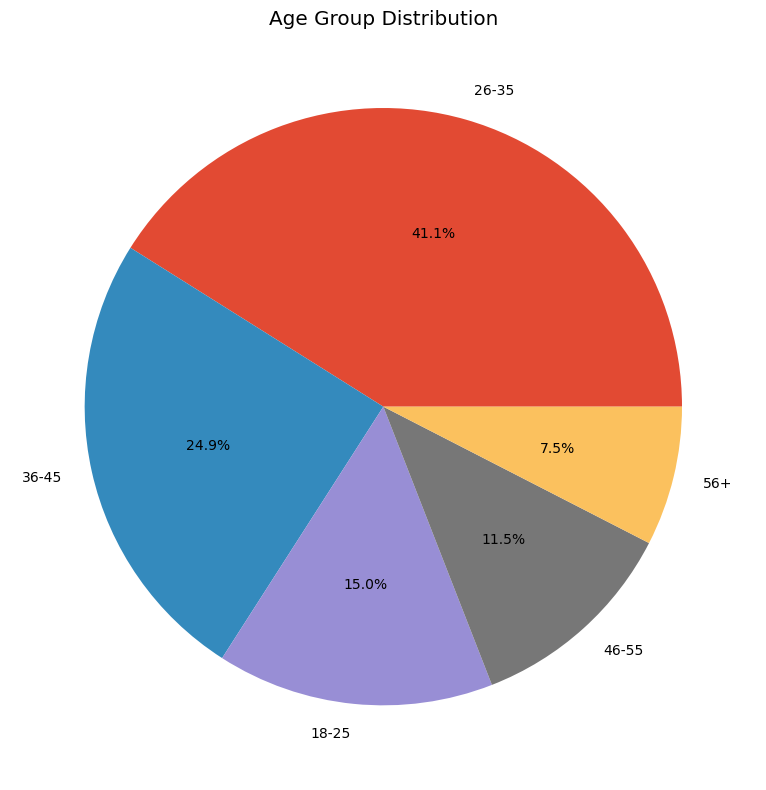

In [28]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Age Group Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/age_group_distribution.png")
plt.show()

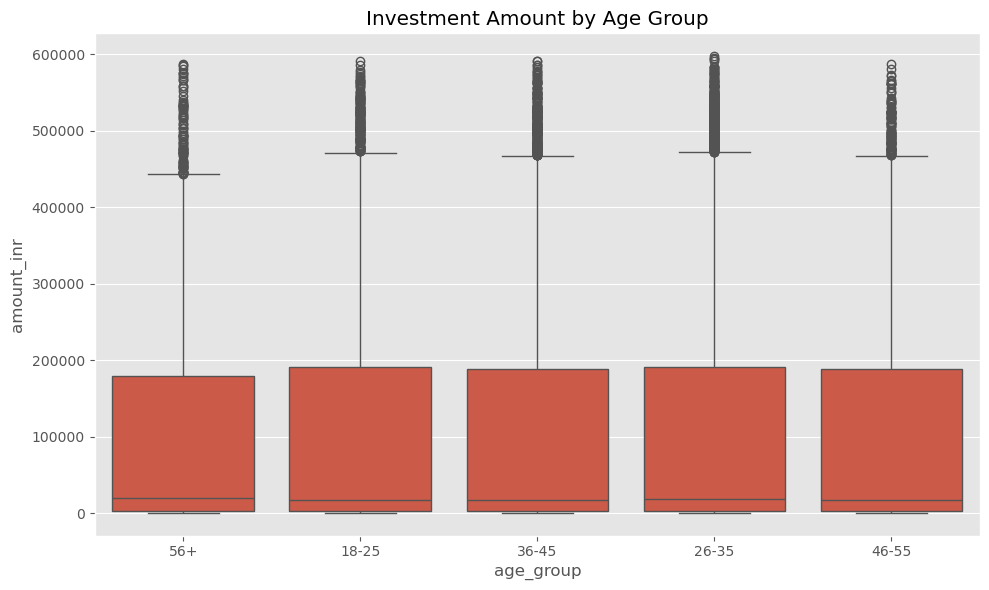

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.tight_layout()
plt.savefig("../reports/figures/invest_amount_age_group.png")
plt.show()

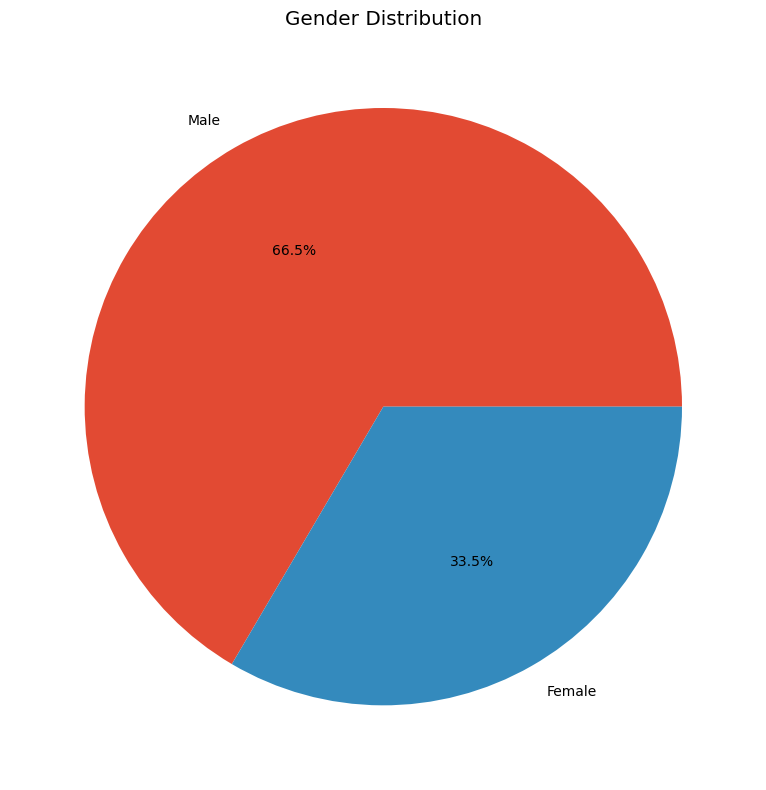

In [29]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/gender_distribution.png")
plt.show()

# State-wise Investment Distribution

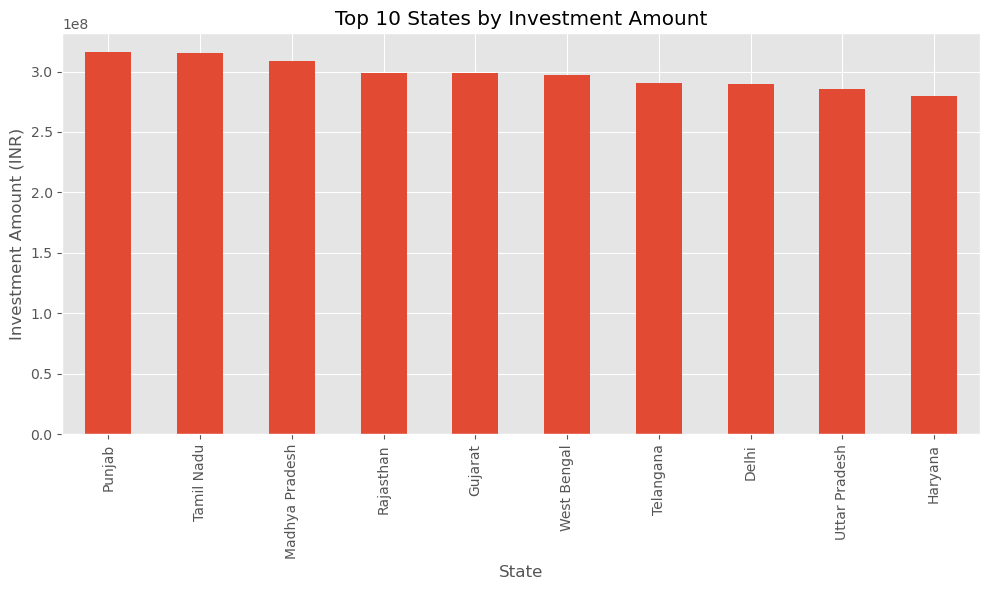

In [30]:
top_states = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_states.plot(kind="bar")

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()
plt.savefig("../reports/figures/top_10_states.png")
plt.show()

# T30 vs B30 Distribution

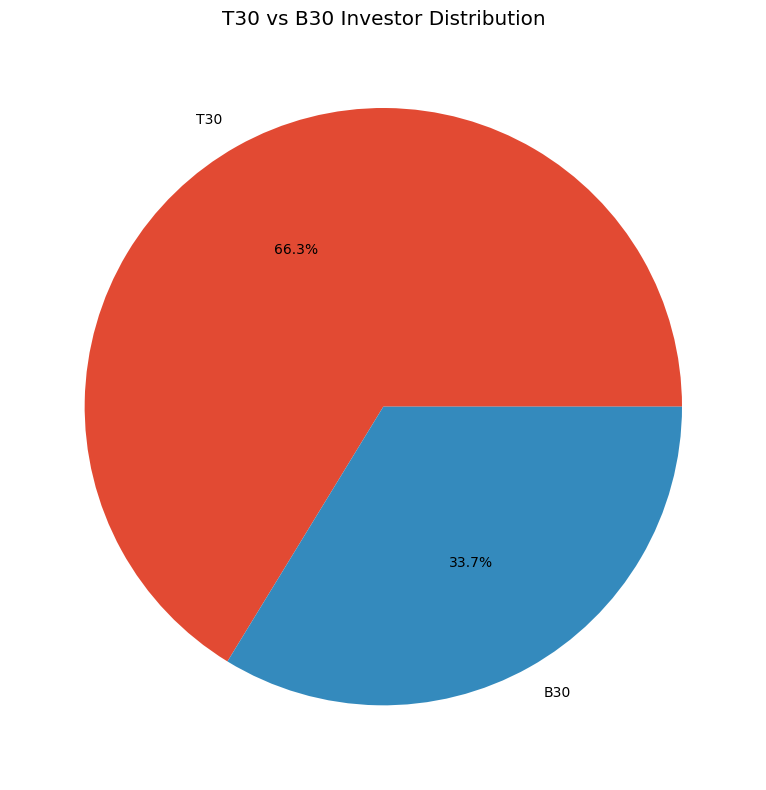

In [31]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30 Investor Distribution")

plt.tight_layout()
plt.savefig("../reports/figures/t30_vs_b30.png")
plt.show()

# Folio Growth Analysis

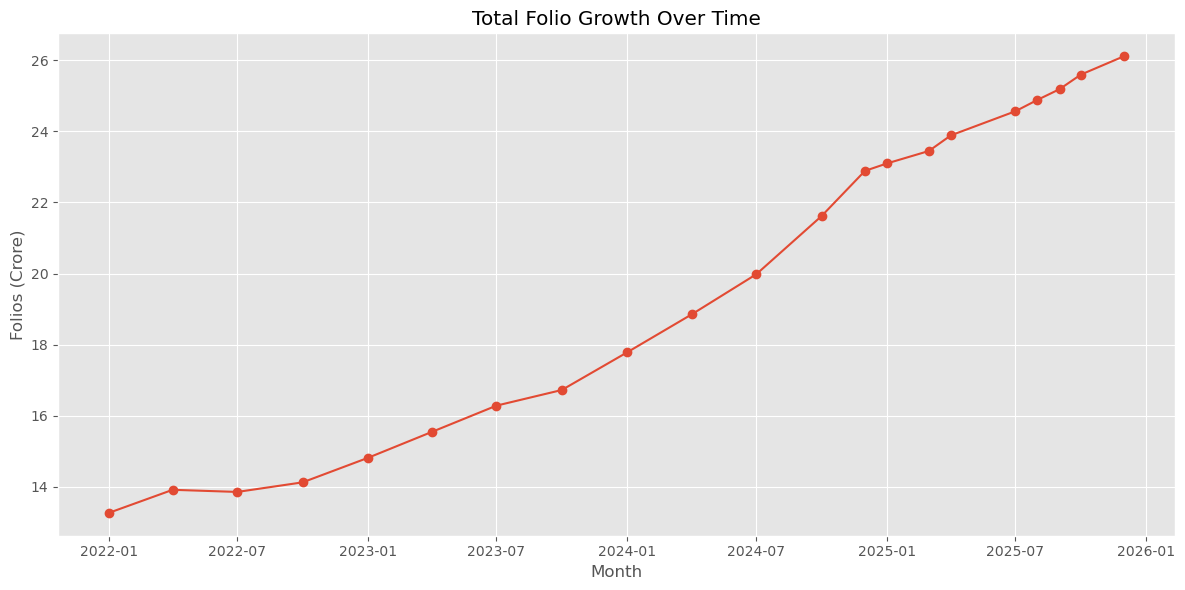

In [32]:
folio_count["month"] = pd.to_datetime(
    folio_count["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folio_count["month"],
    folio_count["total_folios_crore"],
    marker="o"
)

plt.title("Total Folio Growth Over Time")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.tight_layout()
plt.savefig("../reports/figures/folio_growth.png")
plt.show()

# NAV Correlation Analysis

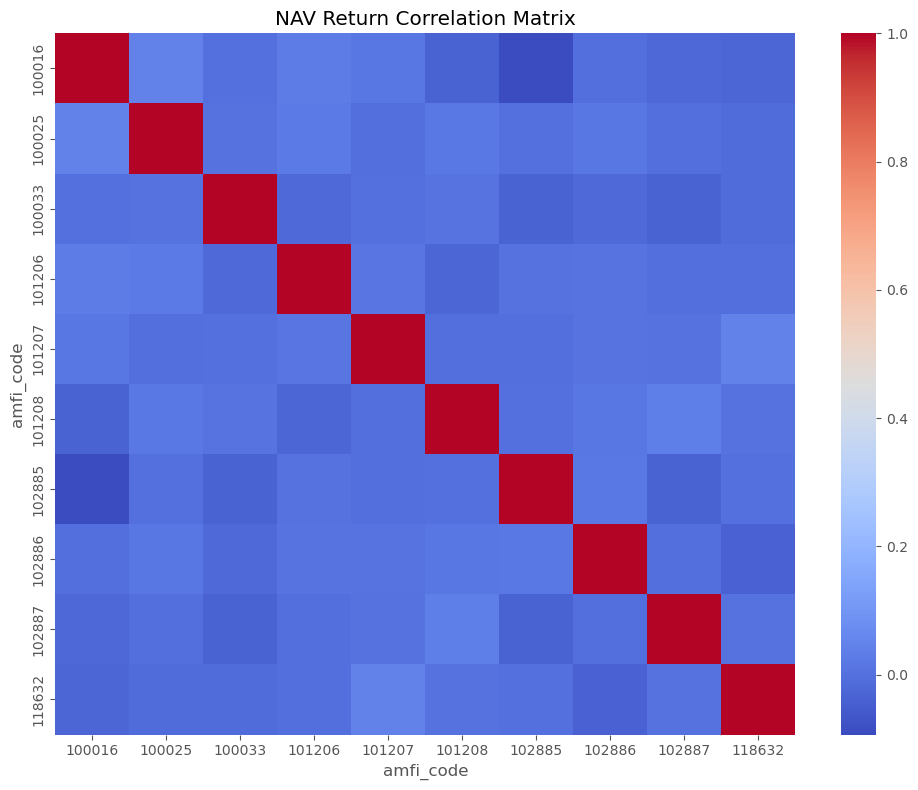

In [33]:
nav_pivot = nav_hist.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix.iloc[:10, :10],
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()
plt.savefig("../reports/figures/nav_correlation_matrix.png")
plt.show()

# Sector Allocation Analysis

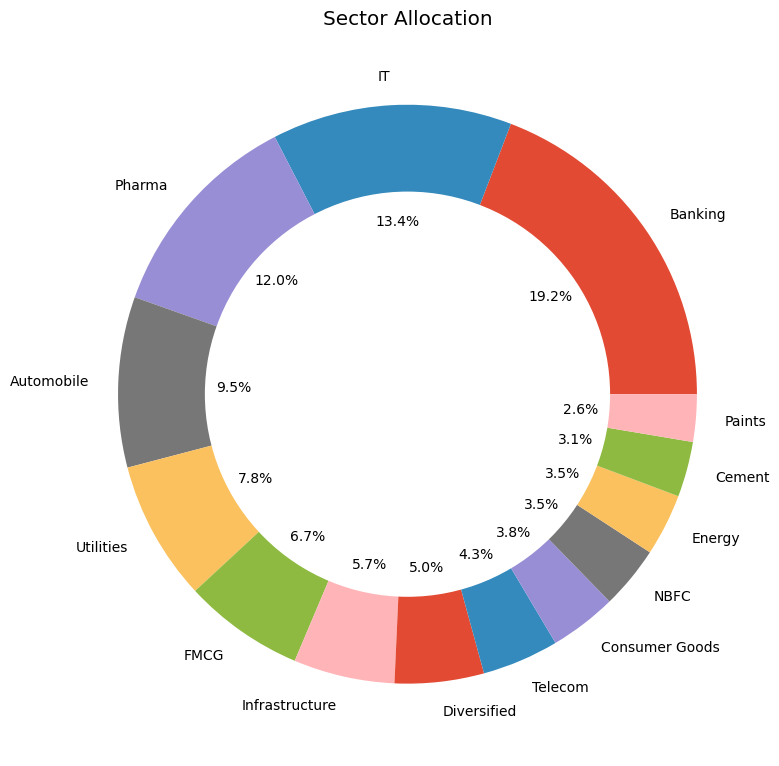

In [34]:
sector_data = (
    port_holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation")

plt.tight_layout()
plt.savefig("../reports/figures/sector_allocation.png")
plt.show()

# Risk Grade Distribution

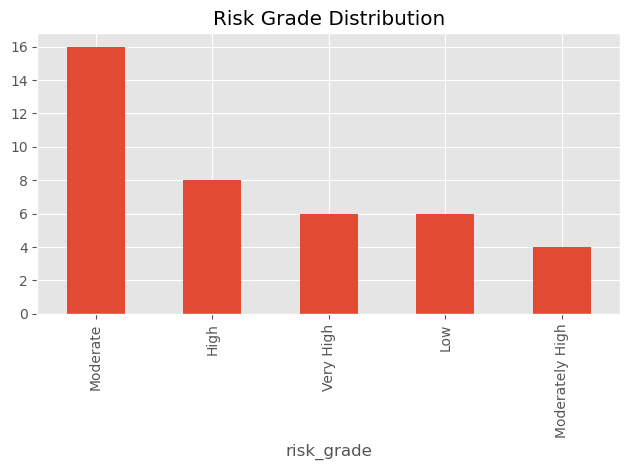

In [35]:
performance["risk_grade"].value_counts().plot(
    kind="bar"
)
plt.title("Risk Grade Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/risk_grade_distribution.png")
plt.show()

# Expense Ratio Distribution

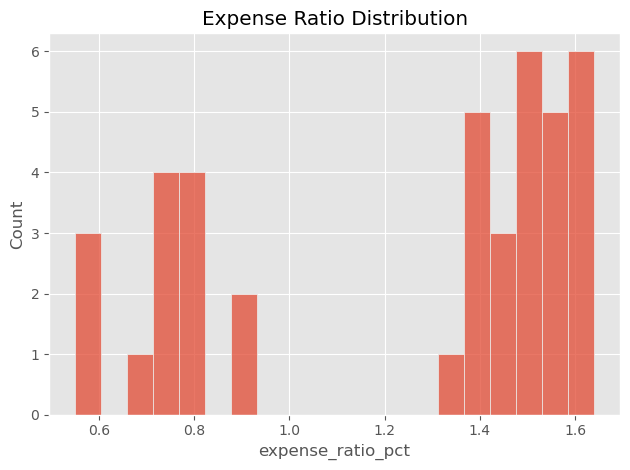

In [36]:
sns.histplot(
    performance["expense_ratio_pct"],
    bins=20
)
plt.title("Expense Ratio Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/expense_ratio_distribution.png")
plt.show()

# Return Distribution

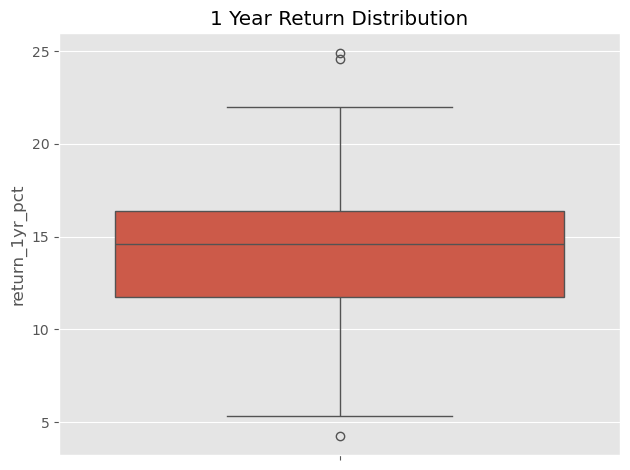

In [37]:
sns.boxplot(
    y=performance["return_1yr_pct"]
)
plt.title("1 Year Return Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/return_1yr_distribution.png")
plt.show()

# Average Return by Category

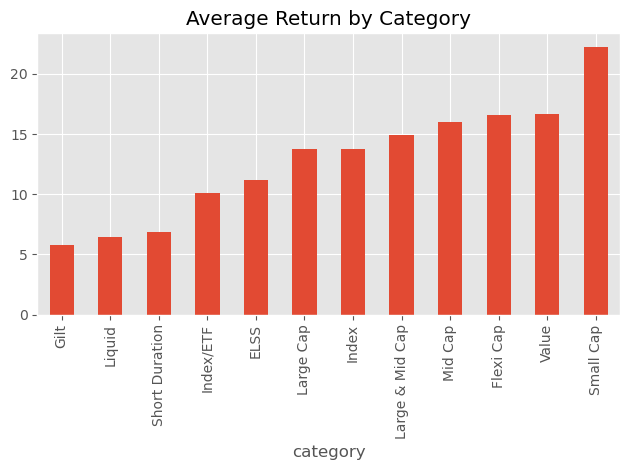

In [38]:
performance.groupby("category")[
    "return_1yr_pct"
].mean().sort_values().plot(
    kind="bar"
)
plt.title("Average Return by Category")
plt.tight_layout()
plt.savefig("../reports/figures/return_by_category.png")
plt.show()

# Key Findings

1. NAV values showed a generally increasing trend across major schemes.
2. AUM growth was concentrated among a few leading fund houses.
3. SIP inflows increased steadily over the analysis period.
4. Certain fund categories consistently attracted higher inflows.
5. Investors aged 30–45 contributed the largest investment volumes.
6. Male investors formed a larger share of the investor base.
7. Investment activity was concentrated in a few major states.
8. T30 cities contributed a significant portion of investments.
9. Total folio counts showed strong long-term growth.
10. Portfolio allocations were concentrated in a few major sectors.